10375.000937499999


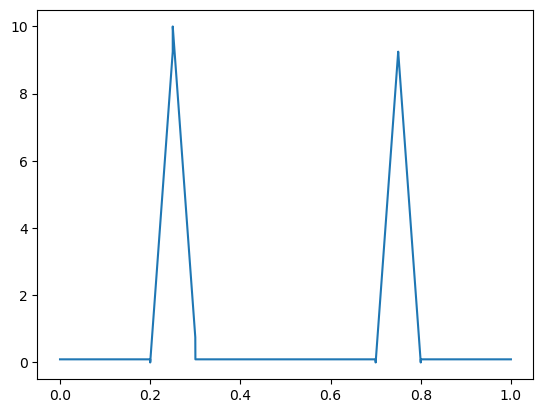

In [14]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = []
prior = []
n = 1000000
for i in range(n):
    x.append(i/n)
    if 0.2 < i/n <= 0.25:
        prior.append(185*(i/n - 0.2))
    elif 0.25 < i/n <= 0.3:
        prior.append(10 - 185*(i/n - 0.25))
    elif 0.7 < i/n <= 0.75:
        prior.append(185*(i/n - 0.7))
    elif 0.75 < i/n < 0.8:
        prior.append(9.25 - 185*(i/n - 0.75))
    else:
        prior.append(0.075/0.8)

print(sum(prior)*0.01)
plt.plot(x, prior)
plt.show()


key: x = 0.518519
value: lkh = 0.152239927933049


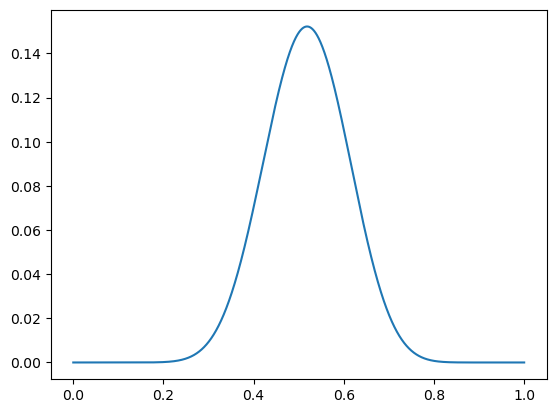

In [15]:
# 小數以下六位，找最高點之x
x = np.array(x)
lkh = sp.factorial(27)/(sp.factorial(14) * sp.factorial(27-14)) * x**14 * (1-x)**(27-14)

dic = {k: v for k, v in zip(x, lkh) if 0.4 <= k <= 0.6}

print(f'key: x = {max(dic, key = dic.get)}')
print(f'value: lkh = {dic[max(dic, key = dic.get)]}')

plt.plot(x, lkh)
plt.show()

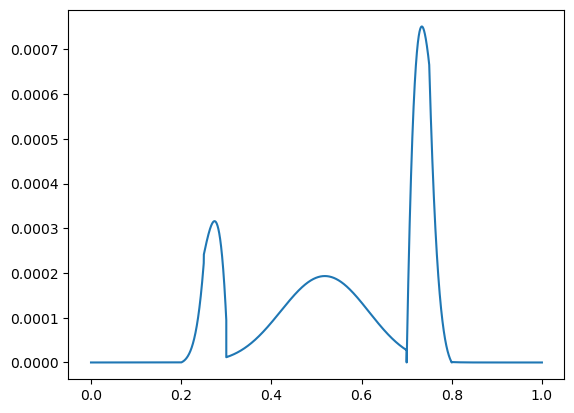

In [16]:
den = sum(prior * lkh * 0.01)
posterior = prior * lkh / den

plt.plot(x, posterior)
plt.show()

In [17]:
dic = {k: v for k, v in zip(x, posterior) if 0.3 <= k <= 0.7}

print(f'key: x = {max(dic, key = dic.get)}')
print(f'value: posterior = {dic[max(dic, key = dic.get)]}')



key: x = 0.518519
value: posterior = 0.000193194457574414


890


(array([0.08233333, 0.        , 0.1885    , 0.        , 0.26433333,
        0.        , 0.3445    , 0.        , 0.40083333, 0.        ,
        0.4095    , 0.        , 0.47666667]),
 array([1.        , 1.46153846, 1.92307692, 2.38461538, 2.84615385,
        3.30769231, 3.76923077, 4.23076923, 4.69230769, 5.15384615,
        5.61538462, 6.07692308, 6.53846154, 7.        ]),
 <BarContainer object of 13 artists>)

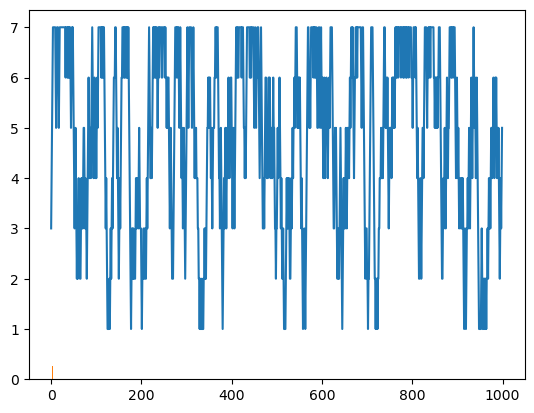

In [23]:
pop = [1,2,3,4,5,6,7]
trajectory = []
x = 3 ; n = 1000
np.random.seed(234)

count = 0
for i in range(n):
    if 1-1 < x < 7-1:
        proposed = np.random.choice([x-1, x+1])
    elif x == 0:
        proposed = np.random.choice([x, x+1])
    elif x == 6:
        proposed = np.random.choice([x-1, x])
    
    if pop[proposed]/pop[x] >= 1:
        x = proposed
        count += 1
    elif np.random.random() < pop[proposed]/pop[x]:
        x = proposed
        count += 1
    trajectory.append(pop[x])

print(count)
plt.plot([i for i in range(n)], trajectory)
plt.hist(trajectory, bins = 13, density = True, width = 0.3)
        